In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
X_train = np.load("D:/PomegranateGuard/dataset/X_train.npy")
X_val   = np.load("D:/PomegranateGuard/dataset/X_val.npy")

y_train = np.load("D:/PomegranateGuard/dataset/y_train.npy")
y_val   = np.load("D:/PomegranateGuard/dataset/y_val.npy")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)


X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")

Train shape: (3938, 224, 224, 3)
Validation shape: (844, 224, 224, 3)


In [3]:
print(X_train.min(), X_train.max())
print(X_val.min(), X_val.max())

0.0 1.0
0.0 1.0


In [4]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.9699507389162562), np.int64(1): np.float64(1.4064285714285714), np.int64(2): np.float64(1.2064950980392157), np.int64(3): np.float64(0.6997157071783937)}


In [5]:
encoder = load_model(
    "D:/PomegranateGuard/model/encoder_model.h5",
    compile=False
)

print("Encoder Loaded")


for layer in encoder.layers[:-5]:
    layer.trainable = False

for layer in encoder.layers[-5:]:
    layer.trainable = True

encoded_output = encoder.output

Encoder Loaded


In [6]:
LEARNING_RATE = 0.00005
DROPOUT = 0.39183388404167396
FILTERS = 16

In [7]:
x = Conv2D(FILTERS, (3,3), activation='relu', padding='same', name="hbo_conv1")(encoded_output)
x = BatchNormalization(name="hbo_bn1")(x)
x = MaxPooling2D((2,2), name="hbo_pool1")(x)

x = Conv2D(FILTERS*2, (3,3), activation='relu', padding='same', name="hbo_conv2")(x)
x = BatchNormalization(name="hbo_bn2")(x)
x = MaxPooling2D((2,2), name="hbo_pool2")(x)

x = Flatten(name="hbo_flatten")(x)

x = Dense(256, activation='relu', name="hbo_dense1")(x)
x = Dropout(DROPOUT, name="hbo_dropout1")(x)

x = Dense(128, activation='relu', name="hbo_dense2")(x)
x = Dropout(DROPOUT/2, name="hbo_dropout2")(x)

output = Dense(4, activation='softmax', name="hbo_output")(x)

In [8]:
final_model = Model(
    inputs=encoder.input,
    outputs=output,
    name="Hybrid_HBO_Model"
)

In [9]:
final_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_model.summary()


Model: "Hybrid_HBO_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_conv1 (Conv2D)                   │ (None, 28, 28, 16)          │          18,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_bn1 (BatchNormalization)         │ (None, 28, 28, 16)          │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_pool1 (MaxPooling2D)             │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_conv2 (Conv2D)                   │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_bn2 (BatchNormalization)         │ (None, 14, 14, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_pool2 (MaxPooling2D)             │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_flatten (Flatten)                │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_dense1 (Dense)                   │ (None, 256)                 │         401,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_dropout1 (Dropout)               │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_dense2 (Dense)                   │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_dropout2 (Dropout)               │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hbo_output (Dense)                   │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 551,604 (2.10 MB)

 Trainable params: 550,612 (2.10 MB)

 Non-trainable params: 992 (3.88 KB)

In [10]:
history = final_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

Epoch 1/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 177s 339ms/step - accuracy: 0.4611 - loss: 1.3278 - val_accuracy: 0.5415 - val_loss: 1.0109
Epoch 2/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 200s 336ms/step - accuracy: 0.6277 - loss: 0.8517 - val_accuracy: 0.5533 - val_loss: 0.9060
Epoch 3/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 201s 334ms/step - accuracy: 0.7321 - loss: 0.6210 - val_accuracy: 0.7761 - val_loss: 0.5788
Epoch 4/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 165s 335ms/step - accuracy: 0.8111 - loss: 0.4630 - val_accuracy: 0.8472 - val_loss: 0.4081
Epoch 5/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 203s 337ms/step - accuracy: 0.8603 - loss: 0.3458 - val_accuracy: 0.7251 - val_loss: 0.5812
Epoch 6/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 166s 336ms/step - accuracy: 0.8979 - loss: 0.2575 - val_accuracy: 0.8744 - val_loss: 0.3249
Epoch 7/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 201s 333ms/step - accuracy: 0.9170 - loss: 0.2279 - val_accuracy: 0.9419 - val_loss: 0.1748
Epoch 8/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 165s 334ms/step - accuracy: 0.9378 -

In [11]:
final_model.save(
    "D:/PomegranateGuard/model/pomegranate_hybrid_hbo_model.h5"
)

print("Final Model Saved")

Final Model Saved


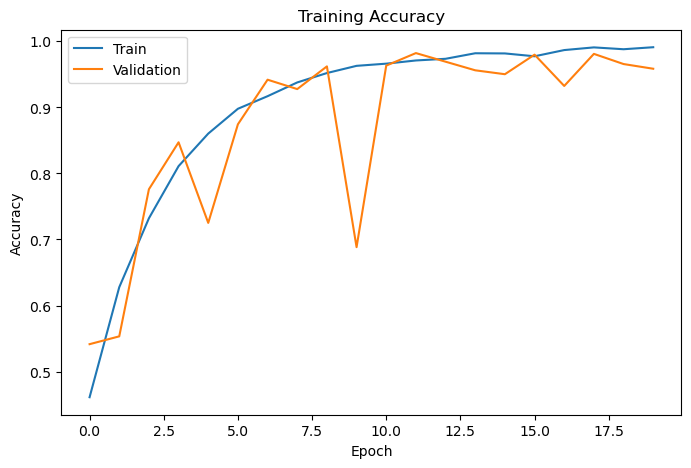

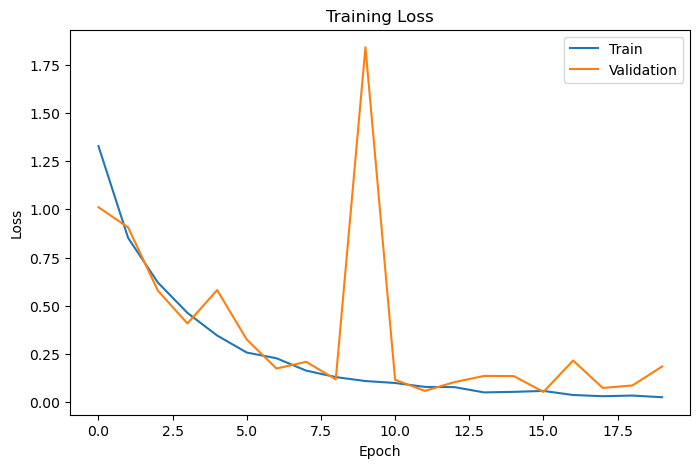

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [60]:
loss, accuracy = final_model.evaluate(X_val, y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.9585 - loss: 0.1853
Validation Loss: 0.18525925278663635
Validation Accuracy: 0.9585307836532593


In [61]:
import numpy as np

y_pred = final_model.predict(X_val)

y_pred_classes = np.argmax(y_pred, axis=1)

print(y_pred_classes[:10])

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step
[3 0 3 1 0 1 3 0 1 0]


In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_classes)

print(cm)


[[217   0   0   0]
 [  2 124   0  24]
 [  0   0 174   1]
 [  5   1   2 294]]


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_classes))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       217
           1       0.99      0.83      0.90       150
           2       0.99      0.99      0.99       175
           3       0.92      0.97      0.95       302

    accuracy                           0.96       844
   macro avg       0.97      0.95      0.96       844
weighted avg       0.96      0.96      0.96       844



In [64]:
final_model.save("D:/PomegranateGuard/model/pomegranate_final_model.h5")

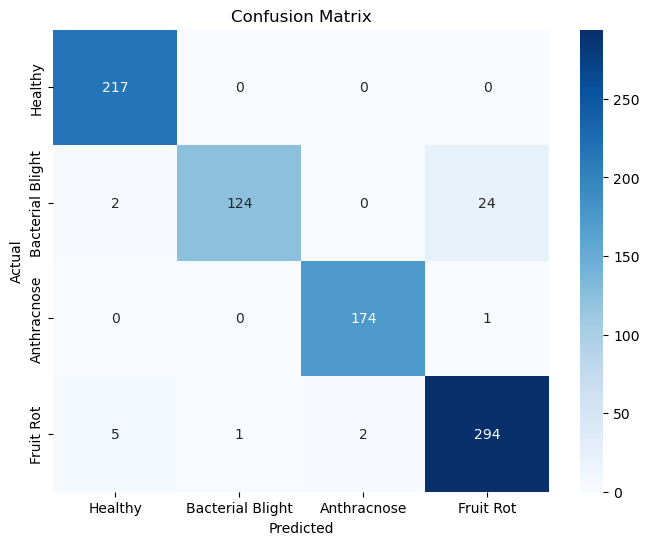

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred_classes)

labels = [
    "Healthy",
    "Bacterial Blight",
    "Anthracnose",
    "Fruit Rot"
]

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("D:\PomegranateGuard\Sample_Fruit_Rot.jpg", target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = final_model.predict(img_array)
class_index = np.argmax(prediction)

classes = [
    "Healthy",
    "Bacterial Blight",
    "Anthracnose",
    "Fruit Rot"
]

print("Prediction:", classes[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Prediction: Fruit Rot
